# Анализ влияния числа наблюдений (`n_observations`) на обучение PINN


In [1]:
import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import os
import json
import warnings
from scipy.interpolate import RegularGridInterpolator

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print('Импорты — OK')

Импорты — OK


In [2]:
from pinn_module_final import (
    make_consistent_config,
    prepare_config,
    compute_metrics,
    build_solution_grid,
    generate_observations,
    generate_collocation_points,
    generate_boundary_points,
    PINN_Source,
    train_adam,
    train_lbfgs,
    evaluate_model,
    device,
)

print(f'Ядро загружено. Устройство: {device}')

Устройство: cuda
run_experiment — OK
Ядро загружено. Устройство: cuda


In [3]:
import os

OUT_DIR = r"D:\PINN_VKR\nobs_results"

os.makedirs(OUT_DIR, exist_ok=True)

print("Папка результатов:")
print(os.path.abspath(OUT_DIR))

Папка результатов:
D:\PINN_VKR\nobs_results


In [ ]:
FIXED_EPOCHS  = 15000
LBFGS_STEPS   = 300     
PRINT_EVERY   = 5_000
EVAL_EVERY    = 2_500
FIXED_NOISE   = 0.001    

N_OBS_VALUES = [4, 9, 25, 64, 100, 225, 400, 900, 1600, 2500]

N_OBS_LABELS = [f'{int(np.sqrt(n))}×{int(np.sqrt(n))}\n({n})' for n in N_OBS_VALUES]
N_OBS_SHORT  = [str(n) for n in N_OBS_VALUES]  # для легенд


TASK_DEFS = {
    'Тест 1: Heat N+N': dict(
        u_exact       = lambda x, t: np.cos(np.pi * x) * np.exp(-t),
        pde_type      = 'heat',
        pde_kwargs    = {'k': 0.3},
        bc_left_type  = 'neumann',
        bc_right_type = 'neumann',
    ),
    'Тест 2: Heat D+D': dict(
        u_exact       = lambda x, t: np.sin(np.pi * x) * np.cos(2 * np.pi * t),
        pde_type      = 'heat',
        pde_kwargs    = {'k': 0.3},
        bc_left_type  = 'dirichlet',
        bc_right_type = 'dirichlet',
    ),
    'Тест 3: Heat D+N': dict(
        u_exact=lambda x, t: (x**2 + 0.5*x + 1) * np.exp(-t),
        pde_type="heat",
        pde_kwargs={"k": 0.2},
        bc_left_type="dirichlet",
        bc_right_type="neumann",
    ),
    'Тест 5: Diffusion D+D': dict(
        u_exact=lambda x, t: np.sin(2*np.pi*x) * np.cos(np.pi*t) +0.5*x*(1-x),
        pde_type="diffusion",
        pde_kwargs={"D": 0.1},
        bc_left_type="dirichlet",
        bc_right_type="dirichlet",
    ),
    'Тест 8: Advection-Diffusion': dict(
        u_exact=lambda x, t: np.sin(np.pi*x) * np.exp(-t),
        pde_type="advection_diffusion",
        pde_kwargs={"k": 0.05, "v": 0.3},
        bc_left_type="dirichlet",
        bc_right_type="dirichlet",
    )
       
}

TASK_EXTRA = {
    'Тест 1: Heat N+N':                 {},
    'Тест 2: Heat D+D ':                {},
    'Тест 3: Heat D+N':                 {},
    'Тест 5: Diffusion D+D':            {},
    'Тест 8: Advection-Diffusion':  {},
}

TASK_COLORS = {
    'Тест 1: Heat N+N':                    '#1f77b4',
    'Тест 2: Heat D+D':                    '#ff7f0e',
    'Тест 3: Heat D+N':                        '#d62728',
    'Тест 5: Diffusion D+D':               '#603270',
    'Тест 8: Advection-Diffusion':     '#647032',
}

print(f'Задачи: {list(TASK_DEFS.keys())}')
print(f'n_observations: {N_OBS_VALUES}')
print(f'Фактические сетки: {[f"{int(np.sqrt(n))}x{int(np.sqrt(n))}" for n in N_OBS_VALUES]}')
print(f'Всего запусков: {len(TASK_DEFS) * len(N_OBS_VALUES)}')
print(f'Результаты → {OUT_DIR}')

Задачи: ['Тест 1: Heat N+N', 'Тест 2: Heat D+D', 'Тест 3: Heat D+N', 'Тест 5: Diffusion D+D', 'Тест 8: Advection-Diffusion']
n_observations: [4, 9, 25, 64, 100, 225, 400, 900, 1600, 2500]
Фактические сетки: ['2x2', '3x3', '5x5', '8x8', '10x10', '15x15', '20x20', '30x30', '40x40', '50x50']
Всего запусков: 50
Результаты → D:\PINN_VKR\nobs_results


In [ ]:
def run_nobs_experiment(task_name, task_def, extra_kwargs, n_observations, seed=42):

    torch.manual_seed(seed)
    np.random.seed(seed)

    n_side = int(np.sqrt(n_observations))
    actual_points = n_side * n_side

    cfg_raw = make_consistent_config(
        **task_def,
        n_observations = n_observations,
        noise_level    = FIXED_NOISE,
        epochs         = FIXED_EPOCHS,
        print_every    = PRINT_EVERY,
        eval_every     = EVAL_EVERY,
        **extra_kwargs,
    )
    cfg = prepare_config(cfg_raw)
    trn = cfg['training']
    dom = cfg['domain']

    x_grid, t_grid, U  = build_solution_grid(cfg)
    x_obs, t_obs, u_obs = generate_observations(x_grid, t_grid, U, cfg)
    x_col, t_col        = generate_collocation_points(cfg)
    boundary            = generate_boundary_points(cfg)

    data = {
        'x_obs': x_obs, 't_obs': t_obs, 'u_obs': u_obs,
        'x_col': x_col, 't_col': t_col, 'boundary': boundary,
    }

    model = PINN_Source(
        hidden_u   = trn['hidden_layers_u'],
        hidden_f   = trn['hidden_layers_f'],
        activation = trn['activation'],
        x_range    = dom['x_range'],
        t_range    = dom['t_range'],
    ).to(device)

    history, _ = train_adam(model, data, cfg)
    train_lbfgs(model, data, cfg)

    final_m = evaluate_model(model, cfg, n_eval=80)
    mf = final_m['f']
    mu = final_m['u']

    return {
        'task':          task_name,
        'n_observations': n_observations,
        'n_side':        n_side,
        'actual_points': actual_points,
        'n_obs_label':   f'{n_side}×{n_side} ({actual_points})',
        # метрики f
        'f_l2_rel':    mf['l2_rel'],
        'f_h1_rel':    mf['h1_rel'],
        'f_linf':      mf['linf'],
        'f_mae':       mf['mae'],
        'f_rmse':      mf['rmse'],

        # метрики u
        'u_l2_rel':    mu['l2_rel'],
        'u_h1_rel':    mu['h1_rel'],
        'u_linf':      mu['linf'],
        'u_mae':       mu['mae'],
        'u_rmse':      mu['rmse'],

        'final_loss':  history['loss'][-1] if history['loss'] else None,
    }

print('run_nobs_experiment — OK')

run_nobs_experiment — OK


## Запуск всех экспериментов


In [ ]:
all_results = []

raw_csv = os.path.join(OUT_DIR, 'nobs_raw_results.csv')

for task_name, task_def in TASK_DEFS.items():
    extra_kwargs = TASK_EXTRA.get(task_name, {})

    print("\n" + "═" * 90)
    print(f"ЗАДАЧА: {task_name}")
    print("═" * 90)

    for n_obs in N_OBS_VALUES:
        print("\n" + "-" * 90)
        print(f"Запуск: {task_name}, n_observations = {n_obs}")
        print("-" * 90)

        result = run_nobs_experiment(
            task_name=task_name,
            task_def=task_def,
            extra_kwargs=extra_kwargs,
            n_observations=n_obs,
            seed=SEED,
        )

        all_results.append(result)
	
        print(
            f"[RESULT] "
            f"n_obs={n_obs:4d} | "
            f"f_L2={result['f_l2_rel']*100:7.3f}% | "
            f"f_H1={result['f_h1_rel']*100:7.3f}% | "
            f"u_L2={result['u_l2_rel']*100:7.3f}% | "
        )
        df = pd.DataFrame(all_results)
        df.to_csv(raw_csv, index=False)

        print(f"✓ Результат сохранён: {raw_csv}")

df = pd.DataFrame(all_results)
print("\nОбучение завершено.")
print(f"Всего строк: {len(df)}")
display(df)


══════════════════════════════════════════════════════════════════════════════════════════
ЗАДАЧА: Тест 1: Heat N+N
══════════════════════════════════════════════════════════════════════════════════════════

------------------------------------------------------------------------------------------
Запуск: Тест 1: Heat N+N, n_observations = 4
------------------------------------------------------------------------------------------
Прогрев 2000 эпох (subnet_f заморожена). Причина: граничное условие Неймана, сложная/осциллирующая f.
   Эпоха |       Loss |     L_bc_L |     L_bc_R |       L_ic |   u_L2%
-----------------------------------------------------------------
       0 |   1.36e+01 |   9.50e-02 |   9.50e-02 |   6.80e-01 | 108.37%
     500 |   1.42e-02 |   2.93e-04 |   2.92e-04 |   1.13e-03 |   9.26%
    1000 |   6.67e-03 |   1.17e-04 |   1.71e-04 |   5.32e-04 |   9.97%
    1500 |   1.74e-03 |   3.67e-05 |   5.91e-05 |   1.20e-04 |   9.33%
    1999 |   1.16e-03 |   2.51e-05 |   4.

,task,n_observations,n_side,actual_points,n_obs_label,f_l2_rel,f_h1_rel,f_linf,f_mae,f_rmse,u_l2_rel,u_h1_rel,u_linf,u_mae,u_rmse,final_loss
0,Тест 1: Heat N+N,4,2,4,2×2 (4),0.293291,0.564926,0.548103,0.234591,0.269588,0.118633,0.141438,0.115296,0.045181,0.055610,0.000032
1,Тест 1: Heat N+N,9,3,9,3×3 (9),0.100868,0.289850,0.216833,0.080575,0.092716,0.012957,0.027989,0.013566,0.005103,0.006074,0.000033
2,Тест 1: Heat N+N,25,5,25,5×5 (25),0.051784,0.235515,0.134956,0.040958,0.047599,0.002522,0.007755,0.002569,0.000972,0.001182,0.000029
3,Тест 1: Heat N+N,64,8,64,8×8 (64),0.032991,0.180400,0.128933,0.025833,0.030325,0.001361,0.004936,0.001497,0.000521,0.000638,0.000029
4,Тест 1: Heat N+N,100,10,100,10×10 (100),0.035649,0.199475,0.154540,0.027877,0.032768,0.001221,0.004812,0.001423,0.000487,0.000573,0.000032
5,Тест 1: Heat N+N,225,15,225,15×15 (225),0.035543,0.205078,0.148886,0.027878,0.032670,0.001077,0.004669,0.001269,0.000430,0.000505,0.000036
6,Тест 1: Heat N+N,400,20,400,20×20 (400),0.038439,0.223463,0.165555,0.030290,0.035333,0.001087,0.004826,0.001300,0.000420,0.000510,0.000033
7,Тест 1: Heat N+N,900,30,900,30×30 (900),0.028676,0.165563,0.141844,0.022284,0.026358,0.000862,0.003783,0.001352,0.000329,0.000404,0.000038
8,Тест 1: Heat N+N,1600,40,1600,40×40 (1600),0.020171,0.115686,0.072879,0.013974,0.018541,0.000701,0.002984,0.000987,0.000268,0.000329,0.000037
9,Тест 1: Heat N+N,2500,50,2500,50×50 (2500),0.030368,0.182028,0.159066,0.023763,0.027914,0.000814,0.003669,0.001176,0.000319,0.000382,0.000052


---
##  Загрузка результатов (для повторного анализа без переобучения)

In [ ]:

raw_csv = os.path.join(OUT_DIR, 'nobs_raw_results.csv')
if 'df' not in dir() or df is None:
    assert os.path.isfile(raw_csv), f'Файл не найден: {raw_csv}'
    df = pd.read_csv(raw_csv)
    print(f'Загружено {len(df)} строк из {raw_csv}')
else:
    print(f'DataFrame уже в памяти: {len(df)} строк')

print(df[['task', 'n_observations', 'n_obs_label', 'f_l2_rel', 'u_l2_rel']].to_string(index=False))

DataFrame уже в памяти: 50 строк
                       task  n_observations  n_obs_label  f_l2_rel  u_l2_rel
           Тест 1: Heat N+N               4      2×2 (4)  0.293291  0.118633
           Тест 1: Heat N+N               9      3×3 (9)  0.100868  0.012957
           Тест 1: Heat N+N              25     5×5 (25)  0.051784  0.002522
           Тест 1: Heat N+N              64     8×8 (64)  0.032991  0.001361
           Тест 1: Heat N+N             100  10×10 (100)  0.035649  0.001221
           Тест 1: Heat N+N             225  15×15 (225)  0.035543  0.001077
           Тест 1: Heat N+N             400  20×20 (400)  0.038439  0.001087
           Тест 1: Heat N+N             900  30×30 (900)  0.028676  0.000862
           Тест 1: Heat N+N            1600 40×40 (1600)  0.020171  0.000701
           Тест 1: Heat N+N            2500 50×50 (2500)  0.030368  0.000814
           Тест 2: Heat D+D               4      2×2 (4)  1.173000  1.370229
           Тест 2: Heat D+D               9

---
## Сводные таблицы по каждой задаче

In [37]:
RENAME = {
    'n_obs_label': 'Сетка (точек)',
    'f_l2_rel':    'f  L2 rel',
    'f_h1_rel':    'f  H1 rel',
    'f_linf':      'f  L∞',
    'f_mae':       'f  MAE',

    'u_l2_rel':    'u  L2 rel',
    'u_h1_rel':    'u  H1 rel',
    'u_linf':      'u  L∞',
    'u_mae':       'u  MAE',

    'final_loss':  'Final Loss',
}

METRICS_F = ['f_l2_rel','f_h1_rel','f_linf','f_mae']
METRICS_U = ['u_l2_rel','u_h1_rel','u_linf','u_mae']

for task_name in TASK_DEFS:
    sub = df[df['task'] == task_name].copy().sort_values('n_observations')
    cols = ['n_obs_label'] + METRICS_F + METRICS_U + ['final_loss']
    tbl  = sub[cols].rename(columns=RENAME).reset_index(drop=True)

    for col_orig, col_new in RENAME.items():
        if any(k in col_orig for k in ['l2_rel','h1_rel']):
            if col_new in tbl.columns:
                tbl[col_new] = sub[col_orig].apply(lambda x: f'{x*100:.4f}%').values

    print(f'\n{"═"*80}')
    print(f'  {task_name}')
    print(f'{"═"*80}')
    display(tbl)

    safe = task_name.replace(':','').replace(' ','_').replace('/','_')
    tbl.to_csv(os.path.join(OUT_DIR, f'table_{safe}.csv'), index=False)
    print(f'  → table_{safe}.csv')


════════════════════════════════════════════════════════════════════════════════
  Тест 1: Heat N+N
════════════════════════════════════════════════════════════════════════════════


,Сетка (точек),f L2 rel,f H1 rel,f L∞,f MAE,u L2 rel,u H1 rel,u L∞,u MAE,Final Loss
0,2×2 (4),29.3291%,56.4926%,0.548103,0.234591,11.8633%,14.1438%,0.115296,0.045181,0.000032
1,3×3 (9),10.0868%,28.9850%,0.216833,0.080575,1.2957%,2.7989%,0.013566,0.005103,0.000033
2,5×5 (25),5.1784%,23.5515%,0.134956,0.040958,0.2522%,0.7755%,0.002569,0.000972,0.000029
3,8×8 (64),3.2991%,18.0400%,0.128933,0.025833,0.1361%,0.4936%,0.001497,0.000521,0.000029
4,10×10 (100),3.5649%,19.9475%,0.154540,0.027877,0.1221%,0.4812%,0.001423,0.000487,0.000032
5,15×15 (225),3.5543%,20.5078%,0.148886,0.027878,0.1077%,0.4669%,0.001269,0.000430,0.000036
6,20×20 (400),3.8439%,22.3463%,0.165555,0.030290,0.1087%,0.4826%,0.001300,0.000420,0.000033
7,30×30 (900),2.8676%,16.5563%,0.141844,0.022284,0.0862%,0.3783%,0.001352,0.000329,0.000038
8,40×40 (1600),2.0171%,11.5686%,0.072879,0.013974,0.0701%,0.2984%,0.000987,0.000268,0.000037
9,50×50 (2500),3.0368%,18.2028%,0.159066,0.023763,0.0814%,0.3669%,0.001176,0.000319,0.000052


  → table_Тест_1_Heat_N+N.csv

════════════════════════════════════════════════════════════════════════════════
  Тест 2: Heat D+D
════════════════════════════════════════════════════════════════════════════════


,Сетка (точек),f L2 rel,f H1 rel,f L∞,f MAE,u L2 rel,u H1 rel,u L∞,u MAE,Final Loss
0,2×2 (4),117.3000%,105.4024%,8.619018,3.243476,137.0229%,113.6584%,1.630251,0.512664,0.000008
1,3×3 (9),81.5796%,108.1405%,9.719941,2.171360,53.8364%,68.5038%,0.756264,0.196666,0.000075
2,5×5 (25),31.0081%,62.8967%,4.099507,0.835163,13.5013%,26.9166%,0.205697,0.047118,0.000072
3,8×8 (64),4.7534%,16.1096%,0.839882,0.117077,1.1898%,4.0169%,0.023325,0.004191,0.000207
4,10×10 (100),1.8611%,6.0362%,0.565290,0.038495,0.1623%,0.5098%,0.003139,0.000622,0.000330
5,15×15 (225),1.8095%,6.2512%,0.578392,0.037612,0.1170%,0.4685%,0.002218,0.000467,0.000333
6,20×20 (400),1.8451%,6.1532%,0.667190,0.034614,0.1043%,0.4063%,0.002406,0.000397,0.000316
7,30×30 (900),1.7821%,6.1488%,0.646378,0.038008,0.1071%,0.4442%,0.002404,0.000422,0.000386
8,40×40 (1600),1.4240%,5.1722%,0.615404,0.026549,0.0764%,0.3361%,0.002195,0.000296,0.000317
9,50×50 (2500),1.7784%,6.2454%,0.684575,0.032706,0.0946%,0.4378%,0.002670,0.000356,0.000315


  → table_Тест_2_Heat_D+D.csv

════════════════════════════════════════════════════════════════════════════════
  Тест 3: Heat D+N
════════════════════════════════════════════════════════════════════════════════


...

  → table_Тест_3_Heat_D+N.csv

════════════════════════════════════════════════════════════════════════════════
  Тест 5: Diffusion D+D
════════════════════════════════════════════════════════════════════════════════


,Сетка (точек),f L2 rel,f H1 rel,f L∞,f MAE,u L2 rel,u H1 rel,u L∞,u MAE,Final Loss
0,2×2 (4),150.4512%,130.9120%,7.230362,3.062373,138.5201%,131.0766%,1.706184,0.507268,0.000090
1,3×3 (9),116.0969%,101.0862%,5.865387,2.347780,100.5879%,97.4912%,1.262629,0.351722,0.000042
2,5×5 (25),49.4581%,76.3944%,3.415181,0.944713,10.7994%,21.8221%,0.132747,0.041513,0.000034
3,8×8 (64),10.8333%,31.3498%,1.782890,0.124392,0.5356%,1.9860%,0.013812,0.001636,0.000088
4,10×10 (100),11.1481%,33.4819%,1.583645,0.145439,0.5517%,2.1259%,0.008720,0.002107,0.000080
5,15×15 (225),5.2243%,22.1805%,0.895125,0.061800,0.1478%,0.6559%,0.002559,0.000593,0.000107
6,20×20 (400),4.9336%,21.5674%,0.822656,0.058444,0.1258%,0.6020%,0.002045,0.000499,0.000110
7,30×30 (900),4.5636%,20.2886%,0.803055,0.050330,0.1116%,0.5428%,0.002000,0.000432,0.000108
8,40×40 (1600),4.3734%,20.1371%,0.830381,0.051869,0.1073%,0.5102%,0.001896,0.000429,0.000099
9,50×50 (2500),4.5103%,19.7011%,0.846723,0.053781,0.1123%,0.5533%,0.002290,0.000456,0.000097


  → table_Тест_5_Diffusion_D+D.csv

════════════════════════════════════════════════════════════════════════════════
  Тест 8: Advection-Diffusion
════════════════════════════════════════════════════════════════════════════════


,Сетка (точек),f L2 rel,f H1 rel,f L∞,f MAE,u L2 rel,u H1 rel,u L∞,u MAE,Final Loss
0,2×2 (4),60.0922%,82.8851%,0.883968,0.228699,24.6718%,29.3785%,0.220452,0.094210,0.000004
1,3×3 (9),15.2418%,34.1854%,0.258110,0.062399,3.9711%,7.8867%,0.035178,0.015354,0.000007
2,5×5 (25),2.9167%,12.5791%,0.068571,0.011560,0.3051%,1.0938%,0.003614,0.001158,0.000007
3,8×8 (64),2.2075%,11.0389%,0.064417,0.008297,0.1667%,0.6195%,0.002320,0.000590,0.000015
4,10×10 (100),2.3993%,11.2888%,0.069076,0.008427,0.1444%,0.6258%,0.002142,0.000530,0.000014
5,15×15 (225),2.2403%,11.0289%,0.070500,0.008047,0.1334%,0.6058%,0.001730,0.000500,0.000016
6,20×20 (400),2.2289%,10.9881%,0.079021,0.008036,0.1326%,0.6069%,0.001780,0.000502,0.000018
7,30×30 (900),1.9809%,9.7038%,0.054049,0.006311,0.0902%,0.4533%,0.001475,0.000329,0.000018
8,40×40 (1600),2.2675%,10.9140%,0.074415,0.008310,0.1365%,0.6269%,0.002103,0.000507,0.000018
9,50×50 (2500),1.9220%,9.5599%,0.052218,0.006310,0.0855%,0.4435%,0.001594,0.000320,0.000019


  → table_Тест_8_Advection-Diffusion.csv


---
## Сводный график: все задачи 

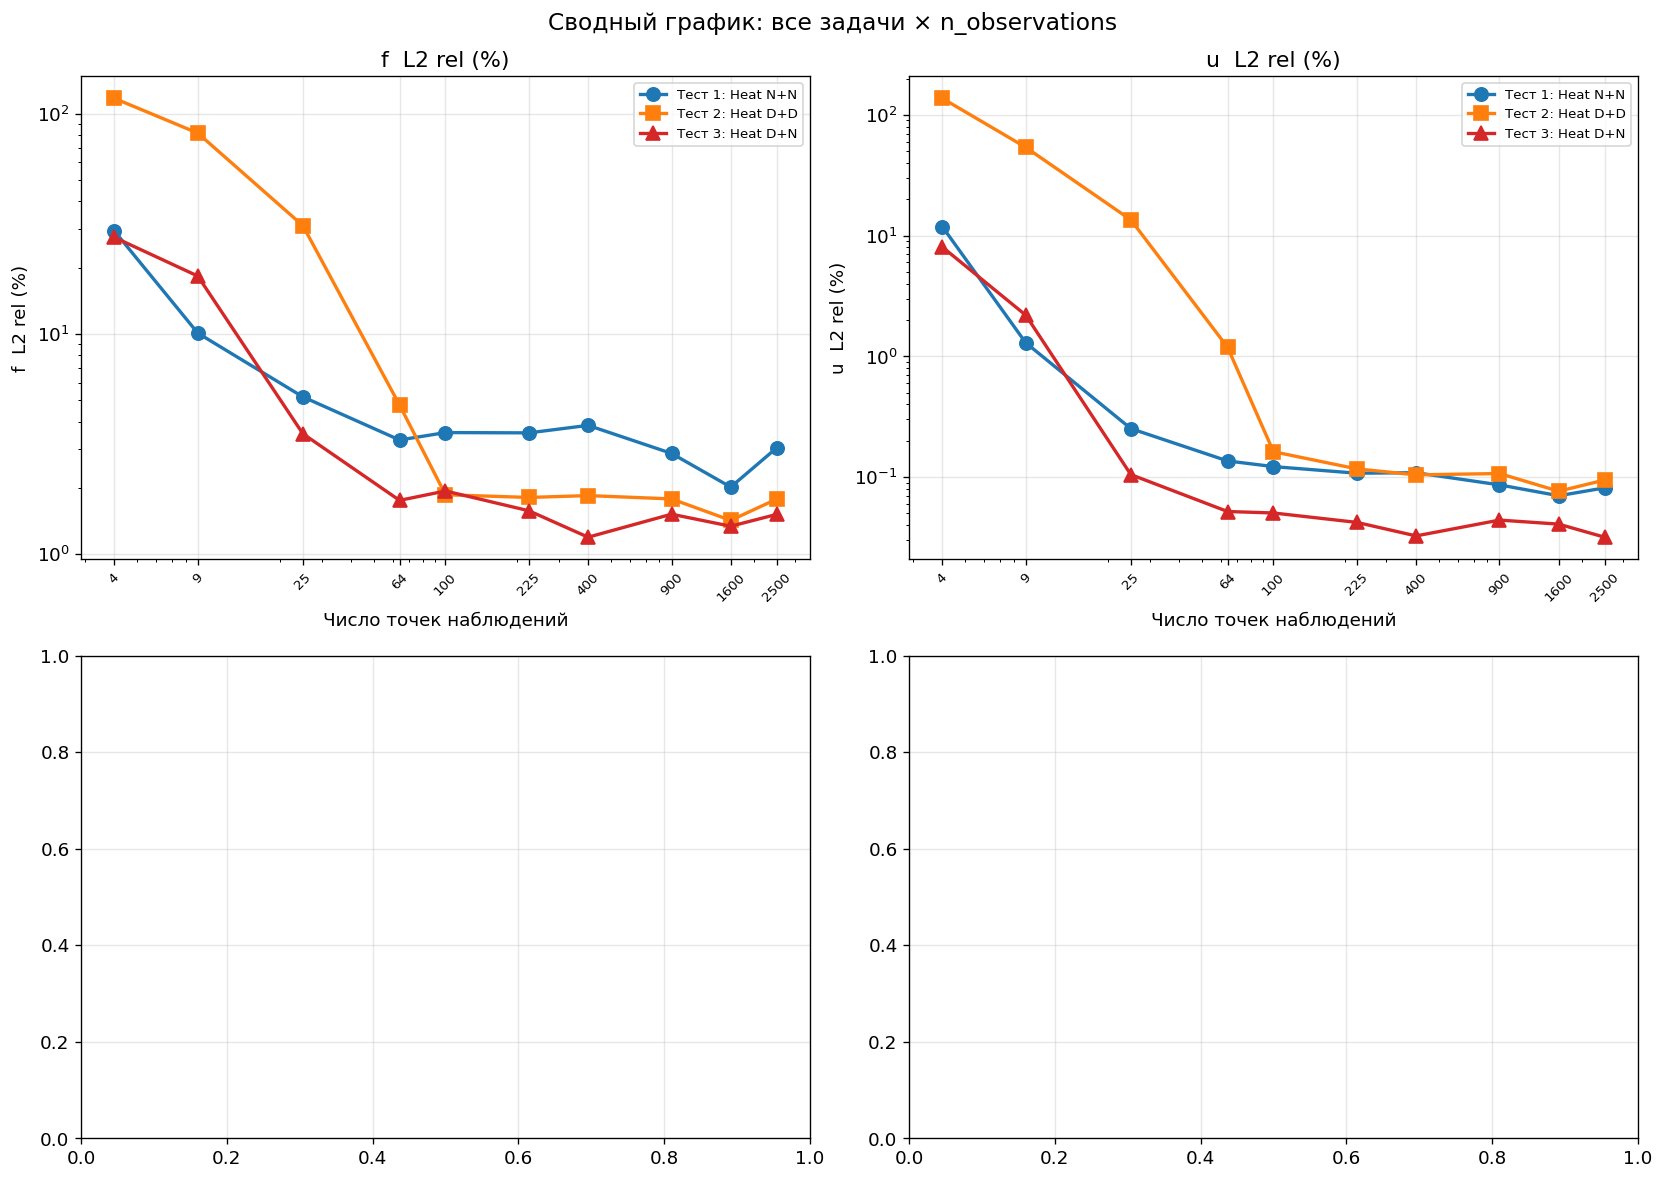

→ summary_all_tasks.png


In [39]:
SUMMARY_METRICS = [
    ('f_l2_rel',    'f  L2 rel (%)',   True,  True),
    ('u_l2_rel',    'u  L2 rel (%)',   True,  True),
]
markers = ['o', 's', '^']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Сводный график: все задачи × n_observations', fontsize=14)

for ax, (col, ylabel, pct, logy) in zip(axes.flat, SUMMARY_METRICS):
    for (task_name, color), marker in zip(TASK_COLORS.items(), markers):
        sub  = df[df['task'] == task_name].sort_values('n_observations')
        xs   = sub['actual_points'].values
        vals = sub[col].values * (100 if pct else 1)
        ax.plot(xs, vals, marker+'-', color=color, lw=2, ms=8, label=task_name)

    ax.set_xlabel('Число точек наблюдений')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.set_xscale('log')
    if logy:
        ax.set_yscale('log')
    ax.set_xticks([4, 9, 25, 64, 100, 225, 400, 900, 1600, 2500])
    ax.set_xticklabels(N_OBS_SHORT, rotation=45, fontsize=8)
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'summary_all_tasks.png'), bbox_inches='tight', dpi=130)
plt.show()
print('→ summary_all_tasks.png')

---
##  Топ-5 лучших и худших конфигураций

In [40]:
TOP_METRIC = 'f_l2_rel'
TOP_N = 5
display_cols = ['task','n_obs_label','f_l2_rel','f_h1_rel','u_l2_rel','u_h1_rel','final_loss']

best_all, worst_all = [], []

for task_name in TASK_DEFS:
    sub   = df[df['task'] == task_name].sort_values(TOP_METRIC)
    best  = sub.head(TOP_N)[display_cols].reset_index(drop=True)
    worst = sub.tail(TOP_N).sort_values(TOP_METRIC, ascending=False)[display_cols].reset_index(drop=True)

    print(f'\n{"─"*70}')
    print(f'{task_name}')
    print(f'  ★ ТОП-{TOP_N} ЛУЧШИХ (min f_L2):')
    display(best)
    print(f'  ✗ ТОП-{TOP_N} ХУДШИХ (max f_L2):')
    display(worst)

    best_all.append(best)
    worst_all.append(worst)

pd.concat(best_all,  ignore_index=True).to_csv(os.path.join(OUT_DIR, 'top5_best.csv'),  index=False)
pd.concat(worst_all, ignore_index=True).to_csv(os.path.join(OUT_DIR, 'top5_worst.csv'), index=False)
print('\n✓ top5_best.csv  /  top5_worst.csv')


──────────────────────────────────────────────────────────────────────
Тест 1: Heat N+N
  ★ ТОП-5 ЛУЧШИХ (min f_L2):


,task,n_obs_label,f_l2_rel,f_h1_rel,u_l2_rel,u_h1_rel,final_loss
0,Тест 1: Heat N+N,40×40 (1600),0.020171,0.115686,0.000701,0.002984,0.000037
1,Тест 1: Heat N+N,30×30 (900),0.028676,0.165563,0.000862,0.003783,0.000038
2,Тест 1: Heat N+N,50×50 (2500),0.030368,0.182028,0.000814,0.003669,0.000052
3,Тест 1: Heat N+N,8×8 (64),0.032991,0.180400,0.001361,0.004936,0.000029
4,Тест 1: Heat N+N,15×15 (225),0.035543,0.205078,0.001077,0.004669,0.000036


  ✗ ТОП-5 ХУДШИХ (max f_L2):


,task,n_obs_label,f_l2_rel,f_h1_rel,u_l2_rel,u_h1_rel,final_loss
0,Тест 1: Heat N+N,2×2 (4),0.293291,0.564926,0.118633,0.141438,0.000032
1,Тест 1: Heat N+N,3×3 (9),0.100868,0.289850,0.012957,0.027989,0.000033
2,Тест 1: Heat N+N,5×5 (25),0.051784,0.235515,0.002522,0.007755,0.000029
3,Тест 1: Heat N+N,20×20 (400),0.038439,0.223463,0.001087,0.004826,0.000033
4,Тест 1: Heat N+N,10×10 (100),0.035649,0.199475,0.001221,0.004812,0.000032



──────────────────────────────────────────────────────────────────────
Тест 2: Heat D+D
  ★ ТОП-5 ЛУЧШИХ (min f_L2):


...


──────────────────────────────────────────────────────────────────────
Тест 8: Advection-Diffusion
  ★ ТОП-5 ЛУЧШИХ (min f_L2):


,task,n_obs_label,f_l2_rel,f_h1_rel,u_l2_rel,u_h1_rel,final_loss
0,Тест 8: Advection-Diffusion,50×50 (2500),0.019220,0.095599,0.000855,0.004435,0.000019
1,Тест 8: Advection-Diffusion,30×30 (900),0.019809,0.097038,0.000902,0.004533,0.000018
2,Тест 8: Advection-Diffusion,8×8 (64),0.022075,0.110389,0.001667,0.006195,0.000015
3,Тест 8: Advection-Diffusion,20×20 (400),0.022289,0.109881,0.001326,0.006069,0.000018
4,Тест 8: Advection-Diffusion,15×15 (225),0.022403,0.110289,0.001334,0.006058,0.000016


  ✗ ТОП-5 ХУДШИХ (max f_L2):


,task,n_obs_label,f_l2_rel,f_h1_rel,u_l2_rel,u_h1_rel,final_loss
0,Тест 8: Advection-Diffusion,2×2 (4),0.600922,0.828851,0.246718,0.293785,0.000004
1,Тест 8: Advection-Diffusion,3×3 (9),0.152418,0.341854,0.039711,0.078867,0.000007
2,Тест 8: Advection-Diffusion,5×5 (25),0.029167,0.125791,0.003051,0.010938,0.000007
3,Тест 8: Advection-Diffusion,10×10 (100),0.023993,0.112888,0.001444,0.006258,0.000014
4,Тест 8: Advection-Diffusion,40×40 (1600),0.022675,0.109140,0.001365,0.006269,0.000018



✓ top5_best.csv  /  top5_worst.csv


---
##  Ранжированный барчарт f_L2 по n_observations

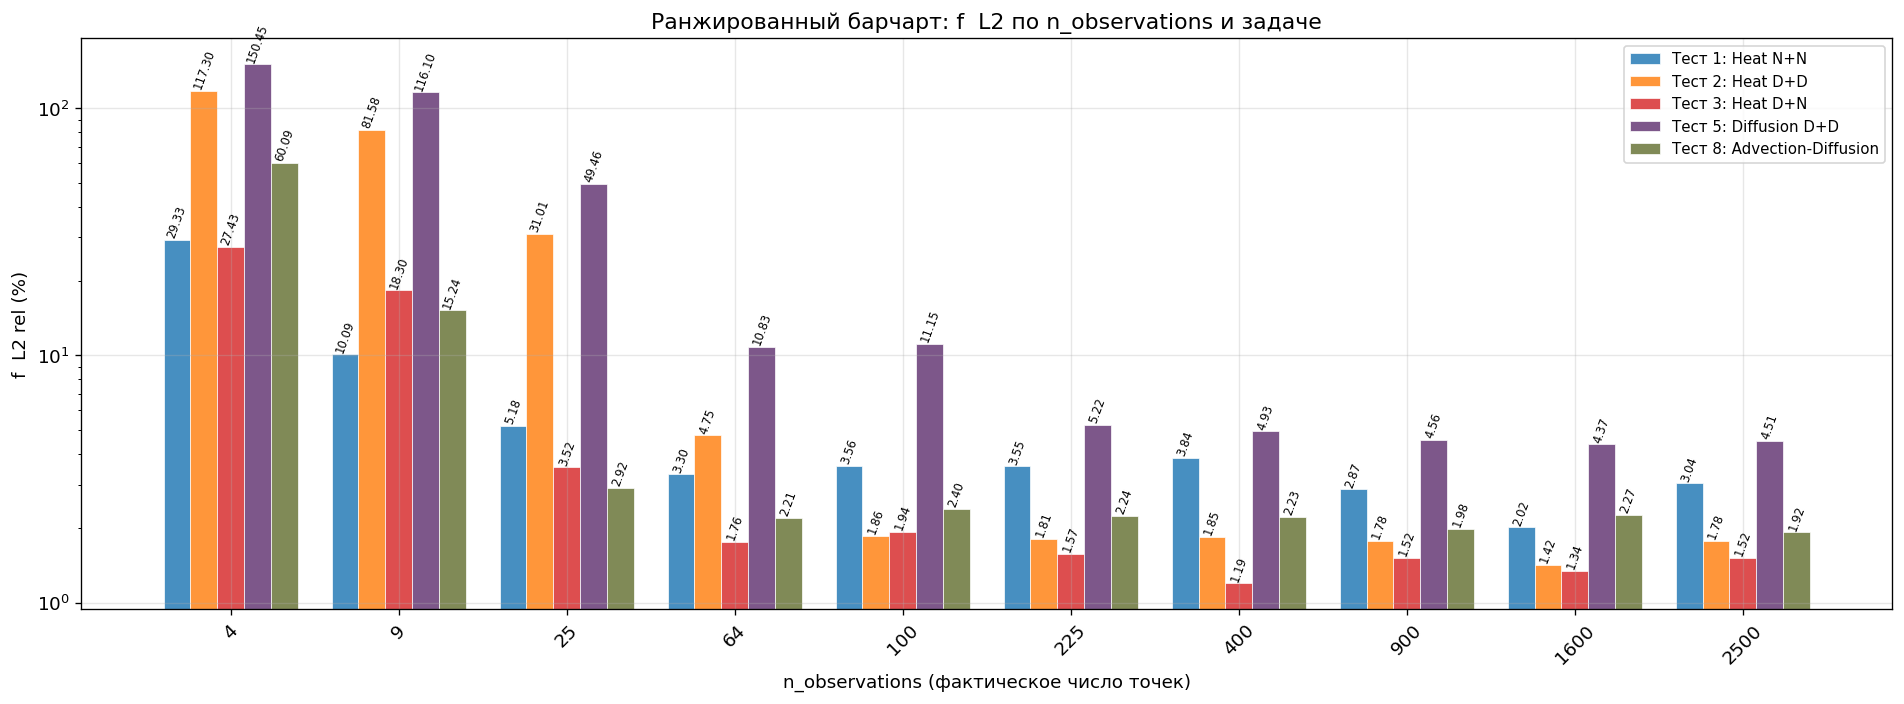

→ barchart_f_l2.png


In [42]:
task_names = list(TASK_DEFS.keys())
n_tasks = len(task_names)
n_nobs  = len(N_OBS_VALUES)
bar_x   = np.arange(n_nobs)
bar_w   = 0.16
offsets = (np.arange(n_tasks) - (n_tasks - 1) / 2) * bar_w

fig, ax = plt.subplots(figsize=(16, 6))

for i, (task_name, color) in enumerate(TASK_COLORS.items()):
    sub  = df[df['task'] == task_name].sort_values('n_observations')
    vals = sub['f_l2_rel'].values * 100
    bars = ax.bar(bar_x + offsets[i], vals, bar_w,
                  label=task_name, color=color, alpha=0.82,
                  edgecolor='white', lw=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f'{v:.2f}', ha='center', va='bottom',
                fontsize=7, rotation=70)

ax.set_xticks(bar_x)
ax.set_xticklabels(N_OBS_SHORT, rotation=45)
ax.set_xlabel('n_observations (фактическое число точек)')
ax.set_ylabel('f  L2 rel (%)')
ax.set_title('Ранжированный барчарт: f  L2 по n_observations и задаче')
ax.set_yscale('log')
ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'barchart_f_l2.png'), bbox_inches='tight', dpi=130)
plt.show()
print('→ barchart_f_l2.png')

---
##  Визуализация расположения точек наблюдений

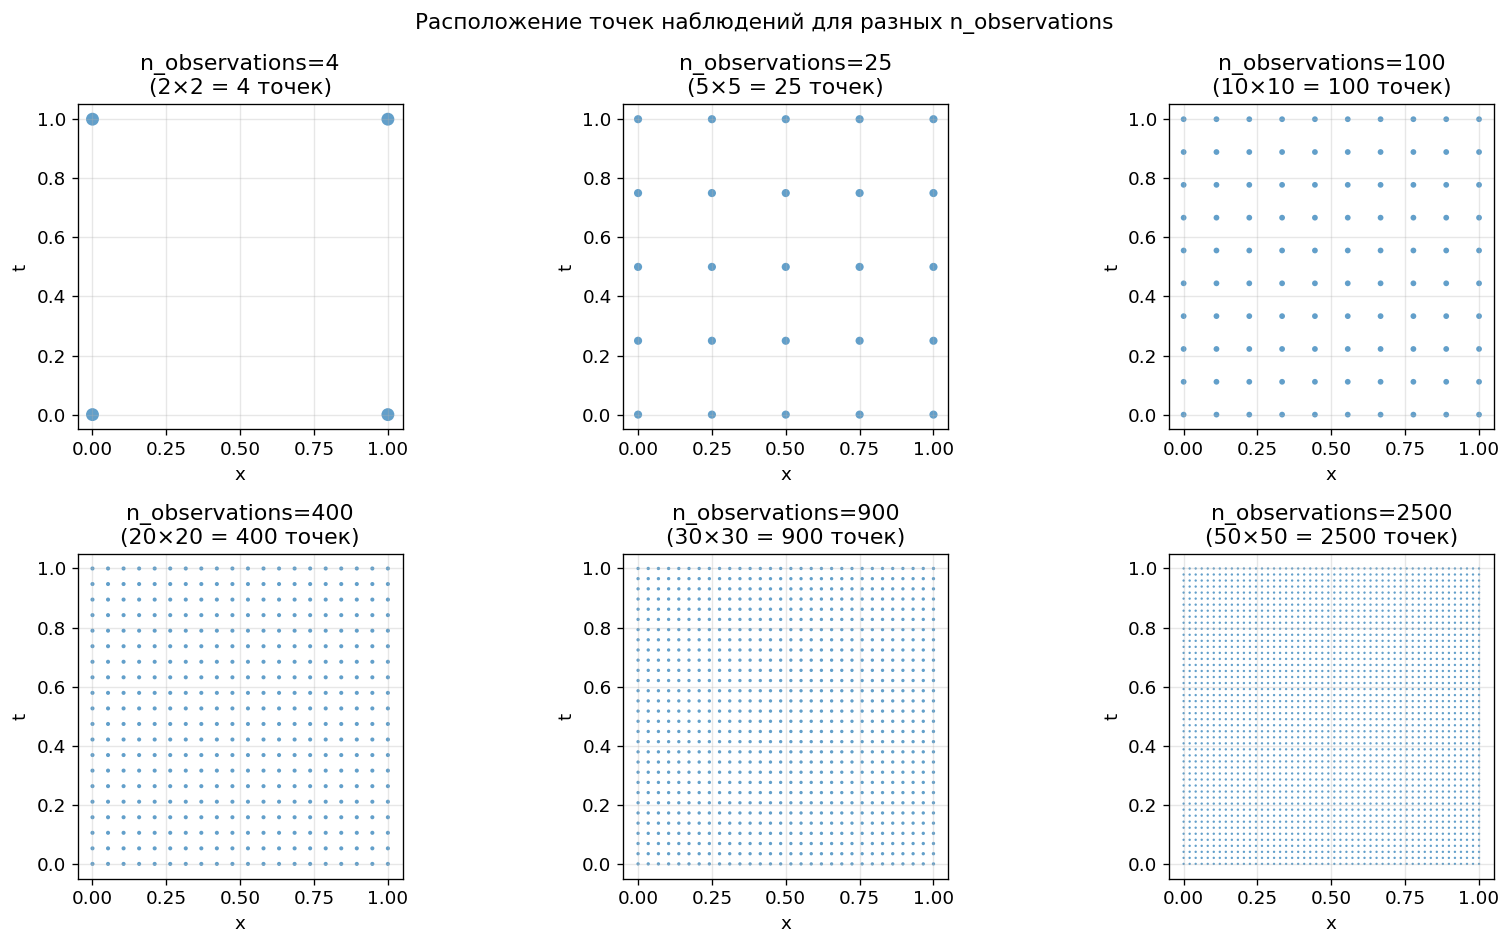

→ observation_grids.png


In [ ]:
SHOW_N_OBS = [4, 25, 100, 400, 900, 2500]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Расположение точек наблюдений для разных n_observations', fontsize=13)

for ax, n_obs in zip(axes.flat, SHOW_N_OBS):
    n_side = int(np.sqrt(n_obs))
    xs = np.linspace(0, 1, n_side)
    ts = np.linspace(0, 1, n_side)
    Xm, Tm = np.meshgrid(xs, ts)

    ax.scatter(Xm.flatten(), Tm.flatten(),
               s=max(1, 120 // n_side), color='#1f77b4',
               alpha=0.7, edgecolors='none')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    ax.set_title(f'n_observations={n_obs}\n({n_side}×{n_side} = {n_side**2} точек)')
    ax.set_aspect('equal')

plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'observation_grids.png'), bbox_inches='tight', dpi=130)
plt.show()
print('→ observation_grids.png')

---
##  Финальная сводная таблица

In [47]:
summary_cols = ['task', 'n_obs_label', 'actual_points',
                'f_l2_rel', 'f_h1_rel', 
                'u_l2_rel', 'u_h1_rel',  'final_loss']
df_summary = df[summary_cols].copy().sort_values(['task', 'actual_points'])

for c in ['f_l2_rel', 'f_h1_rel', 'u_l2_rel', 'u_h1_rel']:
    df_summary[c] = (df_summary[c] * 100).round(4).astype(str) + '%'

df_summary['final_loss'] = df_summary['final_loss'].apply(
    lambda x: f'{x:.3e}' if x is not None else 'N/A'
)

df_summary = df_summary.rename(columns={
    'task': 'Задача',
    'n_obs_label': 'Сетка',
    'actual_points': 'Точек',
    **{k: v for k, v in RENAME.items() if k in summary_cols},
})

display(df_summary)

out_path = os.path.join(OUT_DIR, 'final_summary.csv')
df_summary.to_csv(out_path, index=False)
print(f'\n✓ Финальная таблица → {out_path}')
print(f'\nВсе файлы в папке: {OUT_DIR}')
print('Список файлов:')
for f in sorted(os.listdir(OUT_DIR)):
    size = os.path.getsize(os.path.join(OUT_DIR, f))
    print(f'  {f:<40} {size/1024:.1f} KB')

,Задача,Сетка (точек),Точек,f L2 rel,f H1 rel,u L2 rel,u H1 rel,Final Loss
0,Тест 1: Heat N+N,2×2 (4),4,29.3291%,56.4926%,11.8633%,14.1438%,3.207e-05
1,Тест 1: Heat N+N,3×3 (9),9,10.0868%,28.985%,1.2957%,2.7989%,3.254e-05
2,Тест 1: Heat N+N,5×5 (25),25,5.1784%,23.5515%,0.2522%,0.7755%,2.910e-05
3,Тест 1: Heat N+N,8×8 (64),64,3.2991%,18.04%,0.1361%,0.4936%,2.873e-05
4,Тест 1: Heat N+N,10×10 (100),100,3.5649%,19.9475%,0.1221%,0.4812%,3.184e-05
5,Тест 1: Heat N+N,15×15 (225),225,3.5543%,20.5078%,0.1077%,0.4669%,3.582e-05
6,Тест 1: Heat N+N,20×20 (400),400,3.8439%,22.3463%,0.1087%,0.4826%,3.311e-05
7,Тест 1: Heat N+N,30×30 (900),900,2.8676%,16.5563%,0.0862%,0.3783%,3.752e-05
8,Тест 1: Heat N+N,40×40 (1600),1600,2.0171%,11.5686%,0.0701%,0.2984%,3.704e-05
9,Тест 1: Heat N+N,50×50 (2500),2500,3.0368%,18.2028%,0.0814%,0.3669%,5.177e-05



✓ Финальная таблица → D:\PINN_VKR\nobs_results\final_summary.csv

Все файлы в папке: D:\PINN_VKR\nobs_results
Список файлов:
  barchart_f_l2.png                        92.6 KB
  final_summary.csv                        4.2 KB
  heatmap_rge_f_h1_rel.png                 74.2 KB
  heatmap_rge_f_l2_rel.png                 71.1 KB
  heatmap_rge_u_h1_rel.png                 65.8 KB
  heatmap_rge_u_l2_rel.png                 62.4 KB
  metrics_per_nobs_Тест_1_Heat_N+N.png     136.0 KB
  metrics_per_nobs_Тест_2_Heat_D+D.png     120.8 KB
  metrics_per_nobs_Тест_3_Heat_D+N.png     130.2 KB
  metrics_per_nobs_Тест_5_Diffusion_D+D.png 133.8 KB
  metrics_per_nobs_Тест_8_Advection-Diffusion.png 126.1 KB
  nobs_raw_results.csv                     13.5 KB
  observation_grids.png                    242.5 KB
  relative_growth_error.png                225.2 KB
  scatter_nobs_quality.png                 201.8 KB
  summary_all_tasks.png                    129.4 KB
  table_Тест_1_Heat_N+N.csv               